In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/beauty_products_review_rating/dataset/Train.csv")

In [3]:
test_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/beauty_products_review_rating/dataset/Test.csv")

In [4]:
train_df.head()

,rating,title,text,asin,parent_asin,timestamp,helpful_vote,verified_purchase
0,5,Unique and authentic,A very classy and chic look. This necklace is ...,B0107QYW14,B0107QYW14,1.460000e+12,2,True
1,2,Uncomfortable,The cloth bands tend to scrunch up under my wi...,B08WX159BW,B08WX159BW,1.630000e+12,0,True
2,3,Something has changed for the worse,Really loved this product the first time I bou...,B083F76L79,B083F76L79,1.630000e+12,1,True
3,5,Five Stars,beautiful,B00FBXJ11K,B00FBXJ11K,1.440000e+12,0,True
4,3,1/4 and 3/4,I was so excited to get these. I opened the b...,B00F029PWC,B00F029PWC,1.520000e+12,0,True


In [5]:
train_df.shape

(39986, 8)

In [6]:
test_df.head()

,title,text,asin,parent_asin,timestamp,helpful_vote,verified_purchase,rating
0,just a brush,I didn't realize I was buying just a brush. I...,B07S29RTQZ,B07S29RTQZ,1.610000e+12,0,True,NaN
1,Easy fast and convenient to stay clean,Great for your purse and camping! When the ki...,B07PWLXFR5,B07PWLXFR5,1.600000e+12,0,True,NaN
2,AVOID! Simply thicker personal wipes.,"I expected a larger ""towel."" Disappointed. Th...",B01LXQTVNE,B01LXQTVNE,1.620000e+12,1,True,NaN
3,Five Stars,Great product!,B00N11BR2A,B00N11BR2A,1.520000e+12,2,True,NaN
4,It looks like the picture.,"I don't love it. But, I can and will wear it....",B08D7Q5J6Y,B08D7Q5J6Y,1.630000e+12,0,True,NaN


In [7]:
test_df.shape

(200, 8)

In [8]:
not_in_train_columns = [col for col in test_df.columns if col not in train_df.columns]

In [9]:
len(not_in_train_columns)

0

In [10]:
not_in_test_columns = [col for col in train_df.columns if col not in test_df.columns]

In [11]:
len(not_in_test_columns)

0

In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39986 entries, 0 to 39985
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             39986 non-null  int64  
 1   title              39986 non-null  object 
 2   text               39986 non-null  object 
 3   asin               39986 non-null  object 
 4   parent_asin        39986 non-null  object 
 5   timestamp          39986 non-null  float64
 6   helpful_vote       39986 non-null  int64  
 7   verified_purchase  39986 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(4)
memory usage: 2.2+ MB


In [13]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              200 non-null    object 
 1   text               200 non-null    object 
 2   asin               200 non-null    object 
 3   parent_asin        200 non-null    object 
 4   timestamp          200 non-null    float64
 5   helpful_vote       200 non-null    int64  
 6   verified_purchase  200 non-null    bool   
 7   rating             0 non-null      float64
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 11.3+ KB


In [14]:
train_df['verified_purchase'].value_counts(normalize=True)

verified_purchase
True     0.8565
False    0.1435
Name: proportion, dtype: float64

In [15]:
train_df['rating'].value_counts(normalize=True)

rating
5    0.602836
4    0.137523
1    0.107463
3    0.091982
2    0.060196
Name: proportion, dtype: float64

In [16]:
train_df['asin'].nunique()

21555

In [17]:
train_df['parent_asin'].nunique()

21031

In [18]:
train_df.head()

,rating,title,text,asin,parent_asin,timestamp,helpful_vote,verified_purchase
0,5,Unique and authentic,A very classy and chic look. This necklace is ...,B0107QYW14,B0107QYW14,1.460000e+12,2,True
1,2,Uncomfortable,The cloth bands tend to scrunch up under my wi...,B08WX159BW,B08WX159BW,1.630000e+12,0,True
2,3,Something has changed for the worse,Really loved this product the first time I bou...,B083F76L79,B083F76L79,1.630000e+12,1,True
3,5,Five Stars,beautiful,B00FBXJ11K,B00FBXJ11K,1.440000e+12,0,True
4,3,1/4 and 3/4,I was so excited to get these. I opened the b...,B00F029PWC,B00F029PWC,1.520000e+12,0,True


In [19]:
train_df['helpful_vote'].value_counts(normalize=True)

helpful_vote
0      0.719952
1      0.146376
2      0.051343
3      0.024659
4      0.015180
         ...   
178    0.000025
114    0.000025
66     0.000025
73     0.000025
56     0.000025
Name: proportion, Length: 84, dtype: float64

In [20]:
train_df['timestamp'].value_counts(normalize=True)

timestamp
1.600000e+12    0.064072
1.610000e+12    0.063797
1.580000e+12    0.061271
1.620000e+12    0.060771
1.590000e+12    0.048892
                  ...   
1.050000e+12    0.000075
1.100000e+12    0.000075
1.090000e+12    0.000075
1.040000e+12    0.000050
1.070000e+12    0.000025
Name: proportion, Length: 63, dtype: float64

In [21]:
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'], unit='ms')
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'], unit='ms')

In [22]:
train_df['timestamp'].head()

0   2016-04-07 03:33:20
1   2021-08-26 17:46:40
2   2021-08-26 17:46:40
3   2015-08-19 16:00:00
4   2018-03-02 14:13:20
Name: timestamp, dtype: datetime64[ns]

In [23]:
train_df['text'].nunique()

38326

In [24]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk import pos_tag

In [25]:
train_df['text'] = train_df['text'].str.lower()
test_df['text'] = test_df['text'].str.lower()

In [26]:
train_df['tokens'] = train_df['text'].apply(word_tokenize)
test_df['tokens'] = test_df['text'].apply(word_tokenize)

In [27]:
train_df['tokens'].head()

0    [a, very, classy, and, chic, look, ., this, ne...
1    [the, cloth, bands, tend, to, scrunch, up, und...
2    [really, loved, this, product, the, first, tim...
3                                          [beautiful]
4    [i, was, so, excited, to, get, these, ., i, op...
Name: tokens, dtype: object

In [28]:
train_df['cleaned_tokens'] = train_df['tokens'].apply(lambda x: [word for word in x if word not in stopwords.words('english')])

In [29]:
test_df['cleaned_tokens'] = test_df['tokens'].apply(lambda x: [word for word in x if word not in stopwords.words('english')])

In [30]:
train_df['cleaned_tokens'].head()

0    [classy, chic, look, ., necklace, well, made, ...
1    [cloth, bands, tend, scrunch, wigs, ,, thought...
2    [really, loved, product, first, time, bought, ...
3                                          [beautiful]
4    [excited, get, ., opened, bag, ,, counted, mak...
Name: cleaned_tokens, dtype: object

In [31]:
# remove punctuations

train_df['cleaned_tokens'] = train_df['cleaned_tokens'].apply(lambda x: [word for word in x if word.isalnum()])
test_df['cleaned_tokens'] = test_df['cleaned_tokens'].apply(lambda x: [word for word in x if word.isalnum()])

In [32]:
train_df['cleaned_tokens'].head()

0    [classy, chic, look, necklace, well, made, fee...
1    [cloth, bands, tend, scrunch, wigs, thought, w...
2    [really, loved, product, first, time, bought, ...
3                                          [beautiful]
4    [excited, get, opened, bag, counted, make, sur...
Name: cleaned_tokens, dtype: object

In [33]:
train_df['cleaned_tokens'] = train_df['cleaned_tokens'].apply(lambda x: list(set(x)))
test_df['cleaned_tokens'] = test_df['cleaned_tokens'].apply(lambda x: list(set(x)))

In [34]:
train_df['cleaned_tokens'].head()

0    [look, expensive, neck, authentic, worn, great...
1    [much, place, would, sticks, pulls, bands, wig...
2    [bought, one, area, consistency, 2, last, bit,...
3                                          [beautiful]
4    [positive, review, wo, get, shape, look, suppo...
Name: cleaned_tokens, dtype: object

In [35]:
train_df['lemmatized_tokens'] = train_df['cleaned_tokens'].apply(lambda x: [WordNetLemmatizer().lemmatize(word) for word in x])
test_df['lemmatized_tokens'] = test_df['cleaned_tokens'].apply(lambda x: [WordNetLemmatizer().lemmatize(word) for word in x])

In [36]:
train_df['lemmatized_tokens'].head()

0    [look, expensive, neck, authentic, worn, great...
1    [much, place, would, stick, pull, band, wig, t...
2    [bought, one, area, consistency, 2, last, bit,...
3                                          [beautiful]
4    [positive, review, wo, get, shape, look, suppo...
Name: lemmatized_tokens, dtype: object

In [37]:
train_df['lemmatized_tokens'] = train_df['lemmatized_tokens'].apply(lambda x: list(set(x)))
test_df['lemmatized_tokens'] = test_df['lemmatized_tokens'].apply(lambda x: list(set(x)))

In [38]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/priyanshu.tuli/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [39]:
train_df['pos_tags'] = train_df['lemmatized_tokens'].apply(pos_tag)
test_df['pos_tags'] = test_df['lemmatized_tokens'].apply(pos_tag)

In [40]:
train_df['pos_tags'].head()

0    [(look, NN), (expensive, JJ), (neck, NN), (aut...
1    [(much, JJ), (cloth, NN), (stick, JJ), (place,...
2    [(bought, VBD), (one, CD), (area, NN), (consis...
3                                    [(beautiful, NN)]
4    [(review, NN), (star, NN), (wo, MD), (get, VB)...
Name: pos_tags, dtype: object

In [41]:
from sentence_transformers import SentenceTransformer

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [42]:
train_df['cleaned_text'] = train_df['lemmatized_tokens'].apply(lambda x: ' '.join(x))
test_df['cleaned_text'] = test_df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

In [43]:
from tqdm import tqdm
tqdm.pandas()

In [44]:
import gensim.downloader as api
from gensim.models import KeyedVectors

In [45]:
word_vectors = api.load("glove-wiki-gigaword-50")

In [46]:
def get_sentence_vector(tokenized_sentence):
    vectors = []
    for word in tokenized_sentence:
        try:
            vectors.append(word_vectors[word])
        except:
            pass
    return np.mean(vectors, axis=0) if vectors else np.zeros(word_vectors.vector_size)

In [47]:
train_df['sentence_vector'] = train_df['lemmatized_tokens'].progress_apply(get_sentence_vector)
test_df['sentence_vector'] = test_df['lemmatized_tokens'].progress_apply(get_sentence_vector)

100%|██████████| 200/200 [00:00<00:00, 30125.00it/s]


In [48]:
train_df['sentence_vector'].head()

0    [0.14789437, 0.20197806, -0.3314926, -0.225940...
1    [-0.080727786, -0.07402917, -0.049486723, -0.3...
2    [0.1721732, 0.0014729655, 0.024266414, -0.1376...
3    [0.54623, 1.2042, -1.1288, -0.1325, 0.95529, 0...
4    [0.15819503, 0.09941923, 0.1860873, -0.2185799...
Name: sentence_vector, dtype: object

In [49]:
word_vectors.vector_size

50

In [50]:
train_df.head()

,rating,title,text,asin,parent_asin,timestamp,helpful_vote,verified_purchase,tokens,cleaned_tokens,lemmatized_tokens,pos_tags,cleaned_text,sentence_vector
0,5,Unique and authentic,a very classy and chic look. this necklace is ...,B0107QYW14,B0107QYW14,2016-04-07 03:33:20,2,True,"[a, very, classy, and, chic, look, ., this, ne...","[look, expensive, neck, authentic, worn, great...","[look, expensive, neck, authentic, worn, great...","[(look, NN), (expensive, JJ), (neck, NN), (aut...",look expensive neck authentic worn great feel ...,"[0.14789437, 0.20197806, -0.3314926, -0.225940..."
1,2,Uncomfortable,the cloth bands tend to scrunch up under my wi...,B08WX159BW,B08WX159BW,2021-08-26 17:46:40,0,True,"[the, cloth, bands, tend, to, scrunch, up, und...","[much, place, would, sticks, pulls, bands, wig...","[much, cloth, stick, place, pull, band, tend, ...","[(much, JJ), (cloth, NN), (stick, JJ), (place,...",much cloth stick place pull band tend hair tho...,"[-0.080727786, -0.07402917, -0.049486723, -0.3..."
2,3,Something has changed for the worse,really loved this product the first time i bou...,B083F76L79,B083F76L79,2021-08-26 17:46:40,1,True,"[really, loved, this, product, the, first, tim...","[bought, one, area, consistency, 2, last, bit,...","[bought, one, area, consistency, 2, last, bit,...","[(bought, VBD), (one, CD), (area, NN), (consis...",bought one area consistency 2 last bit give co...,"[0.1721732, 0.0014729655, 0.024266414, -0.1376..."
3,5,Five Stars,beautiful,B00FBXJ11K,B00FBXJ11K,2015-08-19 16:00:00,0,True,[beautiful],[beautiful],[beautiful],"[(beautiful, NN)]",beautiful,"[0.54623, 1.2042, -1.1288, -0.1325, 0.95529, 0..."
4,3,1/4 and 3/4,i was so excited to get these. i opened the b...,B00F029PWC,B00F029PWC,2018-03-02 14:13:20,0,True,"[i, was, so, excited, to, get, these, ., i, op...","[positive, review, wo, get, shape, look, suppo...","[review, star, wo, get, shape, look, suppose, ...","[(review, NN), (star, NN), (wo, MD), (get, VB)...",review star wo get shape look suppose one rele...,"[0.15819503, 0.09941923, 0.1860873, -0.2185799..."


In [51]:
train_df['cleaned_title'] = train_df['title'].progress_apply(lambda x: word_tokenize(x.lower()))
test_df['cleaned_title'] = test_df['title'].progress_apply(lambda x: word_tokenize(x.lower()))

100%|██████████| 200/200 [00:00<00:00, 1896.13it/s]


In [52]:
train_df['cleaned_title'] = train_df['cleaned_title'].apply(lambda x: [word for word in x if word not in stopwords.words('english')])
test_df['cleaned_title'] = test_df['cleaned_title'].apply(lambda x: [word for word in x if word not in stopwords.words('english')])

In [53]:
train_df['cleaned_title'] = train_df['cleaned_title'].apply(lambda x: [word for word in x if word.isalnum()])
test_df['cleaned_title'] = test_df['cleaned_title'].apply(lambda x: [word for word in x if word.isalnum()])

In [54]:
train_df['cleaned_title'] = train_df['cleaned_title'].apply(lambda x: list(set(x)))
test_df['cleaned_title'] = test_df['cleaned_title'].apply(lambda x: list(set(x)))

In [55]:
train_df['lemmatized_title'] = train_df['cleaned_title'].apply(lambda x: [WordNetLemmatizer().lemmatize(word) for word in x])
test_df['lemmatized_title'] = test_df['cleaned_title'].apply(lambda x: [WordNetLemmatizer().lemmatize(word) for word in x])

In [56]:
train_df['lemmatized_title'] = train_df['lemmatized_title'].apply(lambda x: list(set(x)))
test_df['lemmatized_title'] = test_df['lemmatized_title'].apply(lambda x: list(set(x)))

In [57]:
train_df['lemmatized_title'].head()

0            [authentic, unique]
1                [uncomfortable]
2    [changed, something, worse]
3                   [five, star]
4                             []
Name: lemmatized_title, dtype: object

In [58]:
train_df['title_vector'] = train_df['lemmatized_title'].progress_apply(get_sentence_vector)
test_df['title_vector'] = test_df['lemmatized_title'].progress_apply(get_sentence_vector)

100%|██████████| 200/200 [00:00<00:00, 56737.29it/s]


In [59]:
train_df['title_vector'].head()

0    [0.29448152, 0.48065, -0.99999, 0.3195655, 1.1...
1    [0.31032, -0.19082, -0.49259, -0.46891, 0.7744...
2    [0.041893344, -0.29550275, -0.05829333, -0.446...
3    [0.0005099997, 0.98819005, 0.2666975, 0.60995,...
4    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: title_vector, dtype: object

In [60]:
train_df['asin_labels'] = train_df['asin'].astype('category').cat.codes
test_df['asin_labels'] = test_df['asin'].astype('category').cat.codes

In [61]:
train_df['parent_asin_labels'] = train_df['parent_asin'].astype('category').cat.codes
test_df['parent_asin_labels'] = test_df['parent_asin'].astype('category').cat.codes

In [62]:
train_df['asin_labels'].head()

0     4083
1    19539
2    15702
3     1910
4     1884
Name: asin_labels, dtype: int16

In [63]:
train_df['unique_asin_labels_per_parent_asin'] = train_df.groupby('parent_asin')['asin_labels'].transform('nunique')
test_df['unique_asin_labels_per_parent_asin'] = test_df.groupby('parent_asin')['asin_labels'].transform('nunique')

In [64]:
train_df['unique_asin_labels_per_parent_asin'].value_counts(normalize=True)

unique_asin_labels_per_parent_asin
1     0.941079
2     0.024534
3     0.012204
4     0.007453
6     0.003501
5     0.003476
9     0.002951
18    0.001175
8     0.001000
7     0.000900
17    0.000700
12    0.000650
10    0.000375
Name: proportion, dtype: float64

In [65]:
test_df['unique_asin_labels_per_parent_asin'].value_counts(normalize=True)

unique_asin_labels_per_parent_asin
1    1.0
Name: proportion, dtype: float64

In [66]:
train_df['helpful_vote'].describe()

count    39986.000000
mean         0.937403
std          4.675939
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        430.000000
Name: helpful_vote, dtype: float64

In [67]:
train_df['timestamp_day'] = train_df['timestamp'].dt.day
test_df['timestamp_day'] = test_df['timestamp'].dt.day

In [68]:
train_df['timestamp_month'] = train_df['timestamp'].dt.month
test_df['timestamp_month'] = test_df['timestamp'].dt.month

In [69]:
train_df['timestamp_year'] = train_df['timestamp'].dt.year  
test_df['timestamp_year'] = test_df['timestamp'].dt.year

In [70]:
train_df['timestamp_dayofweek'] = train_df['timestamp'].dt.dayofweek
test_df['timestamp_dayofweek'] = test_df['timestamp'].dt.dayofweek

In [71]:
train_df['timestamp_weekofyear'] = train_df['timestamp'].dt.isocalendar().week
test_df['timestamp_weekofyear'] = test_df['timestamp'].dt.isocalendar().week
train_df['timestamp_is_weekend'] = train_df['timestamp_dayofweek'].apply(lambda x: 1 if x in [5, 6] else 0)
test_df['timestamp_is_weekend'] = test_df['timestamp_dayofweek'].apply(lambda x: 1 if x in [5, 6] else 0)

In [72]:
train_df['is_month_start'] = train_df['timestamp'].dt.is_month_start.astype(int)
test_df['is_month_start'] = test_df['timestamp'].dt.is_month_start.astype(int)
train_df['is_month_end'] = train_df['timestamp'].dt.is_month_end.astype(int)
test_df['is_month_end'] = test_df['timestamp'].dt.is_month_end.astype(int)
train_df['is_quarter_start'] = train_df['timestamp'].dt.is_quarter_start.astype(int)
test_df['is_quarter_start'] = test_df['timestamp'].dt.is_quarter_start.astype(int)
train_df['is_quarter_end'] = train_df['timestamp'].dt.is_quarter_end.astype(int)
test_df['is_quarter_end'] = test_df['timestamp'].dt.is_quarter_end.astype(int)

In [73]:
train_df['is_year_start'] = train_df['timestamp'].dt.is_year_start.astype(int)
test_df['is_year_start'] = test_df['timestamp'].dt.is_year_start.astype(int)
train_df['is_year_end'] = train_df['timestamp'].dt.is_year_end.astype(int)
test_df['is_year_end'] = test_df['timestamp'].dt.is_year_end.astype(int)
train_df['is_leap_year'] = train_df['timestamp'].dt.is_leap_year.astype(int)
test_df['is_leap_year'] = test_df['timestamp'].dt.is_leap_year.astype(int)

In [74]:
train_df['timestamp_hour'] = train_df['timestamp'].dt.hour
test_df['timestamp_hour'] = test_df['timestamp'].dt.hour

In [75]:
train_df['time_of_day'] = pd.cut(train_df['timestamp_hour'], bins=[0, 6, 12, 18, 24], labels=['night', 'morning', 'afternoon', 'evening'])
test_df['time_of_day'] = pd.cut(test_df['timestamp_hour'], bins=[0, 6, 12, 18, 24], labels=['night', 'morning', 'afternoon', 'evening'])

In [76]:
train_df['time_of_day'].value_counts(normalize=True)

time_of_day
morning      0.298981
afternoon    0.297753
night        0.228553
evening      0.174712
Name: proportion, dtype: float64

In [77]:
train_df['average_rating_per_asin'] = train_df.groupby('asin')['rating'].transform('mean')
train_df['median_rating_per_asin'] = train_df.groupby('asin')['rating'].transform('median')
train_df['std_rating_per_asin'] = train_df.groupby('asin')['rating'].transform('std')
train_df['min_rating_per_asin'] = train_df.groupby('asin')['rating'].transform('min')
train_df['max_rating_per_asin'] = train_df.groupby('asin')['rating'].transform('max')

In [78]:
for i, group in test_df.groupby('asin'):
    train_group = train_df[train_df['asin'] == i]
    test_df.loc[test_df['asin'] == i, 'average_rating_per_asin'] = train_group['rating'].mean()
    test_df.loc[test_df['asin'] == i, 'median_rating_per_asin'] = train_group['rating'].median()
    test_df.loc[test_df['asin'] == i, 'std_rating_per_asin'] = train_group['rating'].std()
    test_df.loc[test_df['asin'] == i, 'min_rating_per_asin'] = train_group['rating'].min()
    test_df.loc[test_df['asin'] == i, 'max_rating_per_asin'] = train_group['rating'].max()

In [79]:
train_df['average_rating_per_parent_asin'] = train_df.groupby('parent_asin')['rating'].transform('mean')
train_df['median_rating_per_parent_asin'] = train_df.groupby('parent_asin')['rating'].transform('median')
train_df['std_rating_per_parent_asin'] = train_df.groupby('parent_asin')['rating'].transform('std')
train_df['min_rating_per_parent_asin'] = train_df.groupby('parent_asin')['rating'].transform('min')
train_df['max_rating_per_parent_asin'] = train_df.groupby('parent_asin')['rating'].transform('max')

In [80]:
for i, group in test_df.groupby('parent_asin'):
    train_group = train_df[train_df['parent_asin'] == i]
    test_df.loc[test_df['parent_asin'] == i, 'average_rating_per_parent_asin'] = train_group['rating'].mean()
    test_df.loc[test_df['parent_asin'] == i, 'median_rating_per_parent_asin'] = train_group['rating'].median()
    test_df.loc[test_df['parent_asin'] == i, 'std_rating_per_parent_asin'] = train_group['rating'].std()
    test_df.loc[test_df['parent_asin'] == i, 'min_rating_per_parent_asin'] = train_group['rating'].min()
    test_df.loc[test_df['parent_asin'] == i, 'max_rating_per_parent_asin'] = train_group['rating'].max()

In [81]:
train_df.head()

,rating,title,text,asin,parent_asin,timestamp,helpful_vote,verified_purchase,tokens,cleaned_tokens,...,average_rating_per_asin,median_rating_per_asin,std_rating_per_asin,min_rating_per_asin,max_rating_per_asin,average_rating_per_parent_asin,median_rating_per_parent_asin,std_rating_per_parent_asin,min_rating_per_parent_asin,max_rating_per_parent_asin
0,5,Unique and authentic,a very classy and chic look. this necklace is ...,B0107QYW14,B0107QYW14,2016-04-07 03:33:20,2,True,"[a, very, classy, and, chic, look, ., this, ne...","[look, expensive, neck, authentic, worn, great...",...,3.943182,4.0,1.271780,1,5,3.943182,4.0,1.271780,1,5
1,2,Uncomfortable,the cloth bands tend to scrunch up under my wi...,B08WX159BW,B08WX159BW,2021-08-26 17:46:40,0,True,"[the, cloth, bands, tend, to, scrunch, up, und...","[much, place, would, sticks, pulls, bands, wig...",...,2.000000,2.0,NaN,2,2,2.000000,2.0,NaN,2,2
2,3,Something has changed for the worse,really loved this product the first time i bou...,B083F76L79,B083F76L79,2021-08-26 17:46:40,1,True,"[really, loved, this, product, the, first, tim...","[bought, one, area, consistency, 2, last, bit,...",...,3.000000,3.0,NaN,3,3,3.000000,3.0,NaN,3,3
3,5,Five Stars,beautiful,B00FBXJ11K,B00FBXJ11K,2015-08-19 16:00:00,0,True,[beautiful],[beautiful],...,5.000000,5.0,0.000000,5,5,5.000000,5.0,0.000000,5,5
4,3,1/4 and 3/4,i was so excited to get these. i opened the b...,B00F029PWC,B00F029PWC,2018-03-02 14:13:20,0,True,"[i, was, so, excited, to, get, these, ., i, op...","[positive, review, wo, get, shape, look, suppo...",...,3.875000,4.5,1.457738,1,5,3.875000,4.5,1.457738,1,5


In [82]:
train_df['verified_purchase'].value_counts(normalize=True)

verified_purchase
True     0.8565
False    0.1435
Name: proportion, dtype: float64

In [83]:
train_df['verified_purchase'] = train_df['verified_purchase'].astype(int)
test_df['verified_purchase'] = test_df['verified_purchase'].astype(int)

In [84]:
train_df['time_of_day'] = train_df['time_of_day'].astype('category').cat.codes
test_df['time_of_day'] = test_df['time_of_day'].astype('category').cat.codes

In [85]:
train_df['verified_purchase'].value_counts(normalize=True)

verified_purchase
1    0.8565
0    0.1435
Name: proportion, dtype: float64

In [86]:
train_df.columns

Index(['rating', 'title', 'text', 'asin', 'parent_asin', 'timestamp',
       'helpful_vote', 'verified_purchase', 'tokens', 'cleaned_tokens',
       'lemmatized_tokens', 'pos_tags', 'cleaned_text', 'sentence_vector',
       'cleaned_title', 'lemmatized_title', 'title_vector', 'asin_labels',
       'parent_asin_labels', 'unique_asin_labels_per_parent_asin',
       'timestamp_day', 'timestamp_month', 'timestamp_year',
       'timestamp_dayofweek', 'timestamp_weekofyear', 'timestamp_is_weekend',
       'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end',
       'is_year_start', 'is_year_end', 'is_leap_year', 'timestamp_hour',
       'time_of_day', 'average_rating_per_asin', 'median_rating_per_asin',
       'std_rating_per_asin', 'min_rating_per_asin', 'max_rating_per_asin',
       'average_rating_per_parent_asin', 'median_rating_per_parent_asin',
       'std_rating_per_parent_asin', 'min_rating_per_parent_asin',
       'max_rating_per_parent_asin'],
      dtype='object'

In [87]:
target_column = 'rating'

In [88]:
train_df.head()

,rating,title,text,asin,parent_asin,timestamp,helpful_vote,verified_purchase,tokens,cleaned_tokens,...,average_rating_per_asin,median_rating_per_asin,std_rating_per_asin,min_rating_per_asin,max_rating_per_asin,average_rating_per_parent_asin,median_rating_per_parent_asin,std_rating_per_parent_asin,min_rating_per_parent_asin,max_rating_per_parent_asin
0,5,Unique and authentic,a very classy and chic look. this necklace is ...,B0107QYW14,B0107QYW14,2016-04-07 03:33:20,2,1,"[a, very, classy, and, chic, look, ., this, ne...","[look, expensive, neck, authentic, worn, great...",...,3.943182,4.0,1.271780,1,5,3.943182,4.0,1.271780,1,5
1,2,Uncomfortable,the cloth bands tend to scrunch up under my wi...,B08WX159BW,B08WX159BW,2021-08-26 17:46:40,0,1,"[the, cloth, bands, tend, to, scrunch, up, und...","[much, place, would, sticks, pulls, bands, wig...",...,2.000000,2.0,NaN,2,2,2.000000,2.0,NaN,2,2
2,3,Something has changed for the worse,really loved this product the first time i bou...,B083F76L79,B083F76L79,2021-08-26 17:46:40,1,1,"[really, loved, this, product, the, first, tim...","[bought, one, area, consistency, 2, last, bit,...",...,3.000000,3.0,NaN,3,3,3.000000,3.0,NaN,3,3
3,5,Five Stars,beautiful,B00FBXJ11K,B00FBXJ11K,2015-08-19 16:00:00,0,1,[beautiful],[beautiful],...,5.000000,5.0,0.000000,5,5,5.000000,5.0,0.000000,5,5
4,3,1/4 and 3/4,i was so excited to get these. i opened the b...,B00F029PWC,B00F029PWC,2018-03-02 14:13:20,0,1,"[i, was, so, excited, to, get, these, ., i, op...","[positive, review, wo, get, shape, look, suppo...",...,3.875000,4.5,1.457738,1,5,3.875000,4.5,1.457738,1,5


In [89]:
features = ['helpful_vote', 'asin_labels', 'parent_asin_labels', 'unique_asin_labels_per_parent_asin', 'timestamp_day', 'timestamp_month', 
            'timestamp_year', 'timestamp_dayofweek', 'timestamp_weekofyear', 'timestamp_is_weekend', 'is_month_start', 'is_month_end', 
            'is_quarter_start', 'is_quarter_end', 'is_year_start', 'is_year_end', 
            'is_leap_year', 'timestamp_hour', 'time_of_day', 'average_rating_per_asin', 
            'median_rating_per_asin', 'std_rating_per_asin', 'min_rating_per_asin', 'max_rating_per_asin', 
            'average_rating_per_parent_asin', 'median_rating_per_parent_asin', 'std_rating_per_parent_asin', 'min_rating_per_parent_asin', 
            'max_rating_per_parent_asin', 'verified_purchase', 'sentence_vector', 'title_vector']

In [90]:
X = train_df[features]
y = train_df[target_column]

In [91]:
sentence_vector = np.stack(X['sentence_vector'].to_numpy())
title_vector = np.stack(X['title_vector'].to_numpy())

In [92]:
sentence_vector_df = pd.DataFrame(sentence_vector, columns=[f'sentence_vector_{i}' for i in range(sentence_vector.shape[1])])
title_vector_df = pd.DataFrame(title_vector, columns=[f'title_vector_{i}' for i in range(title_vector.shape[1])])

In [93]:
test_sentence_vector = np.stack(test_df['sentence_vector'].to_numpy())
test_title_vector = np.stack(test_df['title_vector'].to_numpy())

In [94]:
test_sentence_vector_df = pd.DataFrame(test_sentence_vector, columns=[f'sentence_vector_{i}' for i in range(test_sentence_vector.shape[1])])
test_title_vector_df = pd.DataFrame(test_title_vector, columns=[f'title_vector_{i}' for i in range(test_title_vector.shape[1])])

In [95]:
selected_test_df = test_df[features]

In [96]:
selected_test_df = pd.concat([selected_test_df, test_sentence_vector_df, test_title_vector_df], axis=1, ignore_index=True)
selected_test_df.columns = features + [f'sentence_vector_{i}' for i in range(sentence_vector.shape[1])] + [f'title_vector_{i}' for i in range(title_vector.shape[1])]
selected_test_df = selected_test_df.drop(columns=['sentence_vector', 'title_vector'])

In [97]:
sentence_vector_df.head()

,sentence_vector_0,sentence_vector_1,sentence_vector_2,sentence_vector_3,sentence_vector_4,sentence_vector_5,sentence_vector_6,sentence_vector_7,sentence_vector_8,sentence_vector_9,...,sentence_vector_40,sentence_vector_41,sentence_vector_42,sentence_vector_43,sentence_vector_44,sentence_vector_45,sentence_vector_46,sentence_vector_47,sentence_vector_48,sentence_vector_49
0,0.147894,0.201978,-0.331493,-0.225941,0.394923,0.089963,-0.207992,-0.182272,-0.156632,0.166996,...,0.027894,0.229832,0.163625,0.209247,0.233343,-0.029029,-0.038923,-0.407214,-0.121675,-0.072721
1,-0.080728,-0.074029,-0.049487,-0.396788,0.382351,0.258147,-0.201846,-0.147206,-0.179618,0.183576,...,-0.154479,0.026045,0.030471,0.168721,0.314280,-0.093567,0.288209,-0.279377,-0.137007,-0.179730
2,0.172173,0.001473,0.024266,-0.137672,0.374822,0.158860,-0.442385,-0.054372,-0.109553,0.220874,...,-0.060569,-0.045544,0.007253,0.132785,0.119046,0.114312,0.032838,-0.007795,-0.025950,0.128845
3,0.546230,1.204200,-1.128800,-0.132500,0.955290,0.040524,-0.478630,-0.339700,-0.280560,0.717610,...,-0.177610,0.144320,0.406580,-0.520030,0.090810,0.082961,-0.021975,-1.621400,0.345790,-0.010919
4,0.158195,0.099419,0.186087,-0.218580,0.405564,0.073041,-0.308431,-0.090931,-0.033928,0.168166,...,-0.016541,-0.028543,0.127264,0.231661,0.008618,0.056263,-0.004685,0.106395,0.045038,0.211455


In [98]:
X = pd.concat([X, sentence_vector_df, title_vector_df], axis=1, ignore_index=True)
X.columns = features + [f'sentence_vector_{i}' for i in range(sentence_vector.shape[1])] + [f'title_vector_{i}' for i in range(title_vector.shape[1])]
X.head()

,helpful_vote,asin_labels,parent_asin_labels,unique_asin_labels_per_parent_asin,timestamp_day,timestamp_month,timestamp_year,timestamp_dayofweek,timestamp_weekofyear,timestamp_is_weekend,...,title_vector_40,title_vector_41,title_vector_42,title_vector_43,title_vector_44,title_vector_45,title_vector_46,title_vector_47,title_vector_48,title_vector_49
0,2,4083,3880,1,7,4,2016,3,14,0,...,0.571615,-0.259295,0.015400,0.365570,-0.081390,0.461405,-0.055600,0.458840,-0.115833,-0.129865
1,0,19539,18924,1,26,8,2021,3,34,0,...,-0.333730,0.102090,0.089581,1.125200,0.117090,0.064341,-0.149270,0.179970,-0.177590,0.673750
2,1,15702,15181,1,26,8,2021,3,34,0,...,-0.653567,-0.158427,0.092460,0.320757,-0.140570,0.113066,-0.046370,0.107457,0.131599,0.616827
3,0,1910,1788,1,19,8,2015,2,34,0,...,-0.285120,0.657089,0.133380,-0.105485,-0.238355,0.019655,-0.082055,-0.289138,-0.357015,-0.272060
4,0,1884,1763,1,2,3,2018,4,9,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [99]:
X = X.drop(['sentence_vector', 'title_vector'], axis=1)

In [100]:
X.columns

Index(['helpful_vote', 'asin_labels', 'parent_asin_labels',
       'unique_asin_labels_per_parent_asin', 'timestamp_day',
       'timestamp_month', 'timestamp_year', 'timestamp_dayofweek',
       'timestamp_weekofyear', 'timestamp_is_weekend',
       ...
       'title_vector_40', 'title_vector_41', 'title_vector_42',
       'title_vector_43', 'title_vector_44', 'title_vector_45',
       'title_vector_46', 'title_vector_47', 'title_vector_48',
       'title_vector_49'],
      dtype='object', length=130)

In [101]:
from sklearn.model_selection import train_test_split

In [102]:
labels = train_df['rating'].unique()

In [103]:
labels

array([5, 2, 3, 4, 1])

In [104]:
train_df['new_rating'] = train_df['rating'] - 1

In [105]:
y = train_df['new_rating']

In [106]:
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [107]:
import xgboost as xgb

In [108]:
from sklearn.utils.class_weight import compute_sample_weight

In [109]:
train_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [110]:
val_weights = compute_sample_weight(class_weight='balanced', y=y_val)

In [111]:
x_train_dmatrix = xgb.DMatrix(data=x_train, label=y_train)
x_val_dmatrix = xgb.DMatrix(data=x_val, label=y_val)

In [112]:
xgb_params = {
    'objective': 'multi:softmax',
    'num_class': len(y.unique()),
    'max_depth': 20,
    'eta': 0.01,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss',
}

In [113]:
xgb_model = xgb.train(params=xgb_params, dtrain=x_train_dmatrix, num_boost_round=1000, evals=[(x_val_dmatrix, 'validation')], early_stopping_rounds=50, verbose_eval=10)    

[0]	validation-mlogloss:1.59128
[10]	validation-mlogloss:1.43174
[20]	validation-mlogloss:1.30212
[30]	validation-mlogloss:1.19375
[40]	validation-mlogloss:1.10187
[50]	validation-mlogloss:1.02247
[60]	validation-mlogloss:0.95326
[70]	validation-mlogloss:0.89258
[80]	validation-mlogloss:0.83914
[90]	validation-mlogloss:0.79191
[100]	validation-mlogloss:0.74989
[110]	validation-mlogloss:0.71209
[120]	validation-mlogloss:0.67828
[130]	validation-mlogloss:0.64790
[140]	validation-mlogloss:0.62080
[150]	validation-mlogloss:0.59630
[160]	validation-mlogloss:0.57420
[170]	validation-mlogloss:0.55420
[180]	validation-mlogloss:0.53622
[190]	validation-mlogloss:0.51980
[200]	validation-mlogloss:0.50505
[210]	validation-mlogloss:0.49166
[220]	validation-mlogloss:0.47952
[230]	validation-mlogloss:0.46843
[240]	validation-mlogloss:0.45841
[250]	validation-mlogloss:0.44933
[260]	validation-mlogloss:0.44105
[270]	validation-mlogloss:0.43355
[280]	validation-mlogloss:0.42678
[290]	validation-mlogloss

In [114]:
val_preds = xgb_model.predict(x_val_dmatrix)

In [115]:
train_preds = xgb_model.predict(x_train_dmatrix)

In [116]:
from sklearn.metrics import classification_report

In [117]:
classification_report(y_val, val_preds)

'              precision    recall  f1-score   support\n\n           0       0.83      0.83      0.83       853\n           1       0.86      0.67      0.75       473\n           2       0.88      0.64      0.74       755\n           3       0.83      0.62      0.71      1094\n           4       0.86      0.97      0.91      4823\n\n    accuracy                           0.86      7998\n   macro avg       0.85      0.75      0.79      7998\nweighted avg       0.86      0.86      0.85      7998\n'

In [118]:
classification_report(y_train, train_preds)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      3444\n           1       1.00      1.00      1.00      1934\n           2       1.00      1.00      1.00      2923\n           3       1.00      1.00      1.00      4405\n           4       1.00      1.00      1.00     19282\n\n    accuracy                           1.00     31988\n   macro avg       1.00      1.00      1.00     31988\nweighted avg       1.00      1.00      1.00     31988\n'

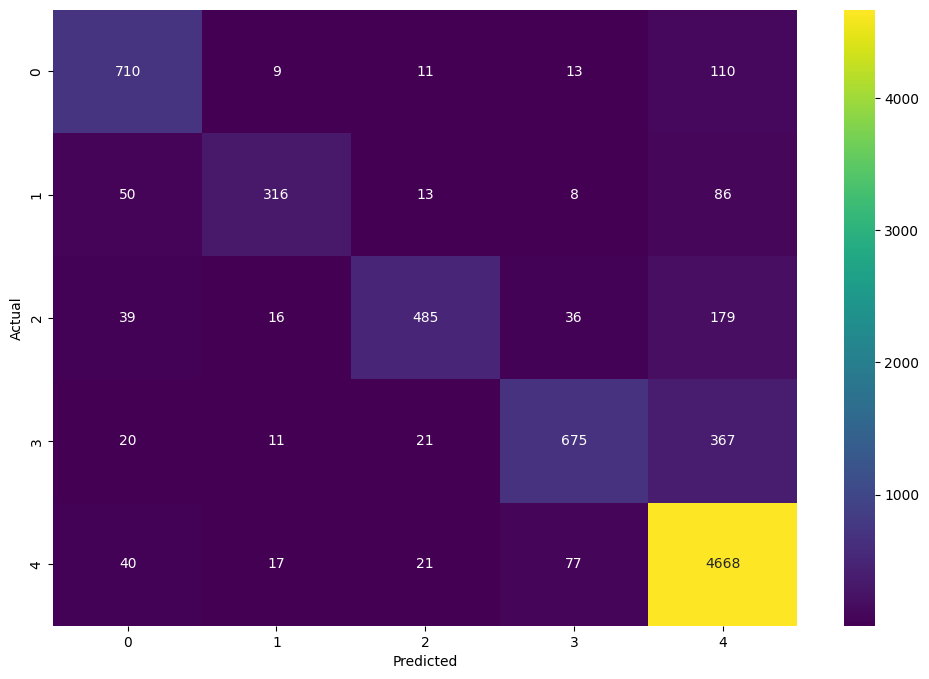

In [129]:
# plot confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [119]:
x_train_full_dmatrix = xgb.DMatrix(data=X, label=y)

In [120]:
xgb_full_model = xgb.train(params=xgb_params, dtrain=x_train_full_dmatrix, num_boost_round=700)

In [121]:
test_dmatrix = xgb.DMatrix(data=selected_test_df)

In [122]:
test_preds = xgb_full_model.predict(test_dmatrix)

In [123]:
test_preds = test_preds + 1

In [124]:
test_df['rating'] = test_preds

In [125]:
submission_df = test_df[['rating']]

In [126]:
submission_df.to_csv("/Users/priyanshu.tuli/Desktop/machinehack/beauty_products_review_rating/xgb_classifier.csv", index=False)

In [127]:
from xgboost import plot_importance

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

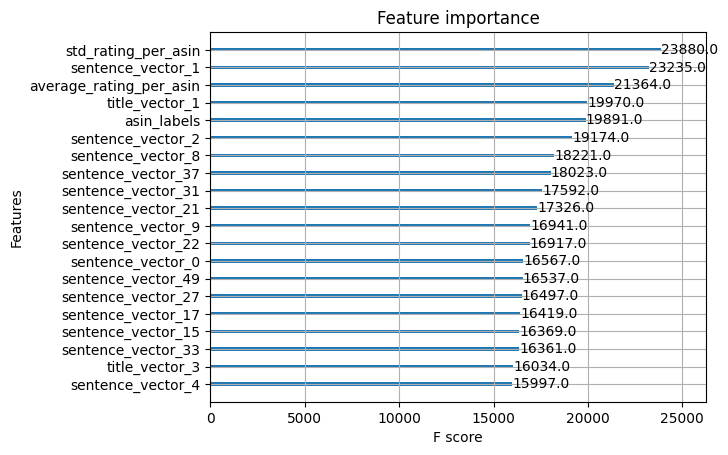

In [128]:
plot_importance(xgb_full_model, importance_type='weight', max_num_features=20)